CONTENTS:
- [AutoGen: An Introduction to Autogen](#autogen:-an-introduction-to-autogen)
    - [Workflow Description](#workflow-description)
  - [Part 1: Dynamic Market Debate & Live Data](#part-1:-dynamic-market-debate-&-live-data)
    - [User Input and Mission](#user-input-and-mission)

<a name='workflow-description'></a>
<a name='autogen:-an-introduction-to-autogen'></a>
# AutoGen: An Introduction to Autogen

This notebook shows some of the advanced use cases of **AutoGen**, such as:
1. **Selection of Agents Dynamically**: Utilizing selector teams to choose the best agent for a specific sub-task.
2. **Handoffs**: Managing transitions between different expert agents.
3. **RAG (Retrieval-Augmented Generation)**: Connecting agents to private vector databases.

To keep things simple in this notebook, we are using **`autogen_agentchat`**, the high-level API built on top of **`autogen-core`**. This provides a more user-friendly interface while still leveraging all the capabilities of AutoGen.

### Workflow Description
In the examples used in this notebook, we are using the **Yahoo Finance API** to fetch data for specified stocks. This data is fed to the agents using specialized tools to generate:
* **Stock Charts**: Visual price trends over a specified period.
* **Financial Reports**: Real-time metrics and strategist debates.

In the second part of the notebook, we manually pull **annual reports (10-K filings)** of a company from their official **SEC filings**. These are cleaned and stored in a **ChromaDB** vector database, allowing the agents to pull high-fidelity evidence using **RAG** tools for deep-dive quantitative analysis.

The 2 cells below import the required libraries and set up the notebook for execution. Please add your API key as required.

In [1]:
%load_ext autoreload
%autoreload 2

import logging
import os
import re

import matplotlib.pyplot as plt
from IPython.display import Image as IPImage
from IPython.display import Markdown, display

# AutoGen Chat Components.
from autogen_agentchat.agents import (
    AssistantAgent,
    CodeExecutorAgent,
    UserProxyAgent,
)
from autogen_agentchat.conditions import TextMentionTermination
from autogen_agentchat.teams import SelectorGroupChat

# AutoGen Extensions.
from autogen_ext.code_executors.local import LocalCommandLineCodeExecutor
from autogen_ext.models.openai import OpenAIChatCompletionClient

import autogen_utils

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

/workspace/autogen_utils.py:244: UserWarning: Using LocalCommandLineCodeExecutor may execute code on the local machine which can be unsafe. For security, it is recommended to use DockerCommandLineCodeExecutor instead. To install Docker, visit: https://docs.docker.com/get-docker/
  code_executor = autogen_ext.code_executors.local.LocalCommandLineCodeExecutor(


In [3]:
# Replace "YOUR_OPENAI_API_KEY" with your actual OpenAI API key.
os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_API_KEY"

<a name='part-1:-dynamic-market-debate-&-live-data'></a>
## Part 1: Dynamic Market Debate & Live Data
**Objective:** Leverage real-time market data to facilitate a debate between opposing investment perspectives.

- **Dynamic Selection:** The `SelectorGroupChat` decides when to call the **Analyst** for data or trigger the **Bull** and **Bear** strategists to debate.
- **Tools:** Integration with `yfinance` via `market_tool` and `plot_tool`.
- **Visualization:** The Analyst generates and displays a technical trend chart directly in the notebook.

In [3]:
async def _run_stock_mission(ticker: str, days: int, task: str, *, model: str = "gpt-4o"):
    model_client = OpenAIChatCompletionClient(model=model)
    # Set up agents.
    analyst = AssistantAgent(
        name="Analyst",
        model_client=model_client,
        tools=[autogen_utils.market_tool, autogen_utils.plot_tool],
        system_message="You ONLY provide raw data and charts. Do NOT interpret or give advice.",
    )
    bull = AssistantAgent(
        name="Bull_Strategist",
        model_client=model_client,
        tools=[autogen_utils.financial_tool],
        system_message="You ONLY look for positives. Speak briefly and wait for the Bear to counter.",
    )
    bear = AssistantAgent(
        name="Bear_Strategist",
        model_client=model_client,
        tools=[autogen_utils.financial_tool],
        system_message="You ONLY look for risks. Speak briefly and challenge the Bull.",
    )
    executive = UserProxyAgent(name="Executive")
    # Set up the selector team.
    team = SelectorGroupChat(
        [analyst, bull, bear, executive],
        model_client=model_client,
        termination_condition=TextMentionTermination("TERMINATE"),
    )
    print(f"\nDYNAMIC DEBATE: {ticker.upper()}")
    print("=" * 45)
    # Stream messages.
    history = []
    async for message in team.run_stream(task=task):
        history.append(message)
        msg_type = str(type(message)).lower()
        if "toolcall" in msg_type or "tool_response" in msg_type:
            continue
        source = message.source.upper()
        if hasattr(message, "content"):
            content_str = str(message.content)
            # Render image.
            # Check for "autogen_core" or the markdown attachment syntax.
            if "autogen_core" in content_str or "attachment://" in content_str:
                if source == "ANALYST":
                    print(f"\n[{source}]: Rendering market trend chart...")
                    # Use the ticker-based filename the utility saves.
                    chart_filename = f"{ticker_in.upper()}_chart.png"
                    if os.path.exists(chart_filename):
                        display(IPImage(filename=chart_filename))
                    else:
                        print(f"Chart file {chart_filename} not found yet.")
                continue
            # Render text.
            text = content_str.strip()
            if text and not text.startswith("ToolResponse"):
                print(f"\n[{source}]: {text}")
        if "TERMINATE" in str(message.content).upper():
            break
    return history

<a name='user-input-and-mission'></a>
### User Input and Mission
The cell below:
- Collects ticker and days for analysis.
- Lets user pick mission type: standard, bear-case, or peer comparison.
- Maps choice to a task and runs `run_stock_mission`.

Ticker:  TSLA
Days:  360



--- Mission Options ---
1. Standard Debate (Press Enter)
2. Focus only on the Bear case
3. Compare this stock to industry peers


Select 1, 2, or 3:  1



 DYNAMIC DEBATE: TSLA

[USER]: Analyst: Provide data for TSLA (360 days). Bull and Bear: Debate the value.


Enter your response:  Show me the stock chart of the company



[EXECUTIVE]: Show me the stock chart of the company

[ANALYST]: 📊 Rendering market trend chart...


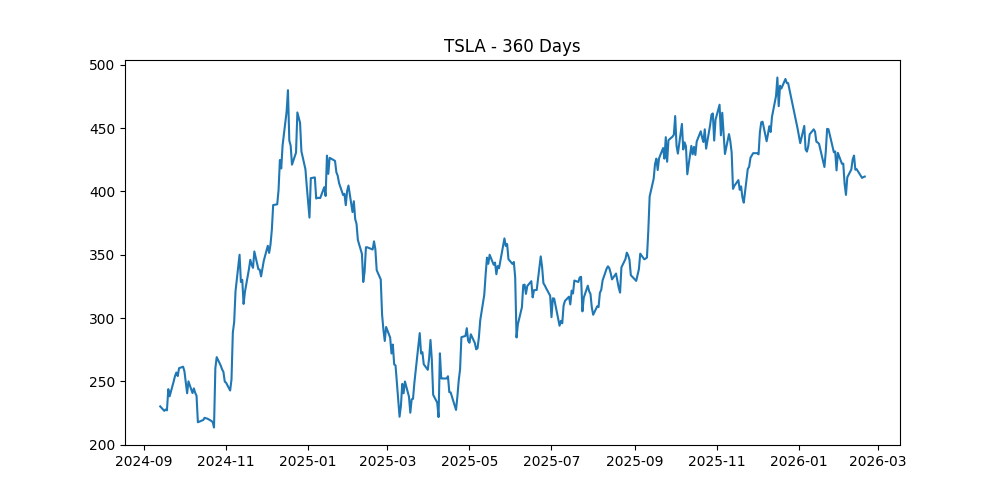

Enter your response:  Give me all the financial numbers of company in a neat table format. Ensure details such as P/E ratio etc are fetched. 



[EXECUTIVE]: Give me all the financial numbers of company in a neat table format. Ensure details such as P/E ratio etc are fetched.

[ANALYST]: ```
| Financial Metric                | Value          |
|---------------------------------|----------------|
| Price/Earnings (Trailing)       | 384.5794       |
| Forward P/E                     | 146.73788      |
| Profit Margin                   | 0.040009998    |
| Revenue Growth (YoY)            | -0.031         |
| Debt to Equity                  | 17.763         |
```

[BULL_STRATEGIST]: TSLA's financials show great potential with impressive P/E ratios indicating high investor confidence. The company has managed debt efficiently and maintained profitability. 

Now, Bear, your counterpoints?

[BEAR_STRATEGIST]: Certainly, the high P/E ratio is worth a deeper examination. It suggests that the stock might be overvalued, reflecting excessive investor optimism rather than fundamental financial strength. A decline in revenue growth (YoY) by 

Enter your response:  Now that both of you have stated your perspectives, can you tell me if I should buy or sell the stock? 



[EXECUTIVE]: Now that both of you have stated your perspectives, can you tell me if I should buy or sell the stock?

[BULL_STRATEGIST]: TSLA's strong investor confidence, innovative edge in the EV market, and resilient profit margins despite industry challenges suggest a promising buy for potential long-term gains. Please consider market conditions and your risk tolerance.

[BEAR_STRATEGIST]: Caution is advised. The high P/E ratio and negative revenue growth point to potential overvaluation and operational challenges. The elevated debt-to-equity ratio also raises stability concerns. Consider these risks carefully before deciding.


Enter your response:  terminate



[EXECUTIVE]: terminate
Enter your response: 

In [5]:
# Set user inputs.
ticker_in = input("Ticker: ").upper().strip()
days_in = int(input("Days: "))
print("\n--- Mission Options ---")
print("1. Standard Debate (Press Enter)")
print("2. Focus only on the Bear case")
print("3. Compare this stock to industry peers")
user_choice = input("Select 1, 2, or 3: ").strip()
# Map numbers to task instructions.
tasks = {
    "1": f"Analyst: Provide data for {ticker_in} ({days_in} days). Bull and Bear: Debate the value.",
    "2": f"Analyst: Provide data. Bear_Strategist: Give a deep dive on every risk you find.",
    "3": f"Analyst: Provide data. Bull and Bear: Debate how {ticker_in} stacks up against its main competitors.",
}
# Default task if the user enters an invalid option.
final_task = tasks.get(user_choice, f"Debate {ticker_in} based on {days_in} days of data.")
# Execute the mission.
history = await _run_stock_mission(ticker=ticker_in, days=days_in, task=final_task)